<a href="https://colab.research.google.com/github/roshika1235/Data_Analysis_Tasks/blob/main/Logistic_Regression_task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## LOGISTIC REGRESSION IMPLEMENTATION


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import  confusion_matrix,classification_report,accuracy_score
from sklearn.datasets import load_breast_cancer

In [ ]:
## data preparation
data=load_breast_cancer()
df=pd.DataFrame(data.data,columns=data.feature_names)
df["Cancer"]=data.target

In [ ]:
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
df['mean radius'].unique()
df['mean texture'].unique()
df['mean perimeter'].unique()
df['mean area'].unique()
df['mean smoothness'].unique()
df['mean compactness'].unique()
df['mean concavity'].unique()
df['mean concave points'].unique()
df['mean symmetry'].unique()

array([0.2419, 0.1812, 0.2069, 0.2597, 0.1809, 0.2087, 0.1794, 0.2196,
       0.235 , 0.203 , 0.1528, 0.1842, 0.2397, 0.1847, 0.2303, 0.1586,
       0.2164, 0.1582, 0.1885, 0.1967, 0.1815, 0.2521, 0.1769, 0.1995,
       0.304 , 0.2252, 0.1697, 0.1926, 0.1739, 0.2183, 0.2301, 0.2248,
       0.1853, 0.1998, 0.1896, 0.1467, 0.1565, 0.172 , 0.1784, 0.1895,
       0.231 , 0.1974, 0.1746, 0.1907, 0.2128, 0.1675, 0.1495, 0.1353,
       0.1868, 0.2092, 0.1616, 0.192 , 0.1917, 0.2027, 0.1819, 0.1683,
       0.2743, 0.1828, 0.1949, 0.2341, 0.1905, 0.1953, 0.1717, 0.1516,
       0.2111, 0.159 , 0.1902, 0.1927, 0.1662, 0.1798, 0.2403, 0.2152,
       0.2906, 0.1718, 0.1942, 0.1829, 0.1634, 0.2079, 0.2132, 0.2075,
       0.193 , 0.2116, 0.1685, 0.1386, 0.1638, 0.1855, 0.2095, 0.19  ,
       0.135 , 0.162 , 0.1879, 0.1609, 0.1945, 0.2217, 0.1925, 0.1801,
       0.1602, 0.2556, 0.1487, 0.1584, 0.1735, 0.1704, 0.1922, 0.1649,
       0.1688, 0.1305, 0.2157, 0.2096, 0.2129, 0.1667, 0.1966, 0.2655,
      

<Axes: >

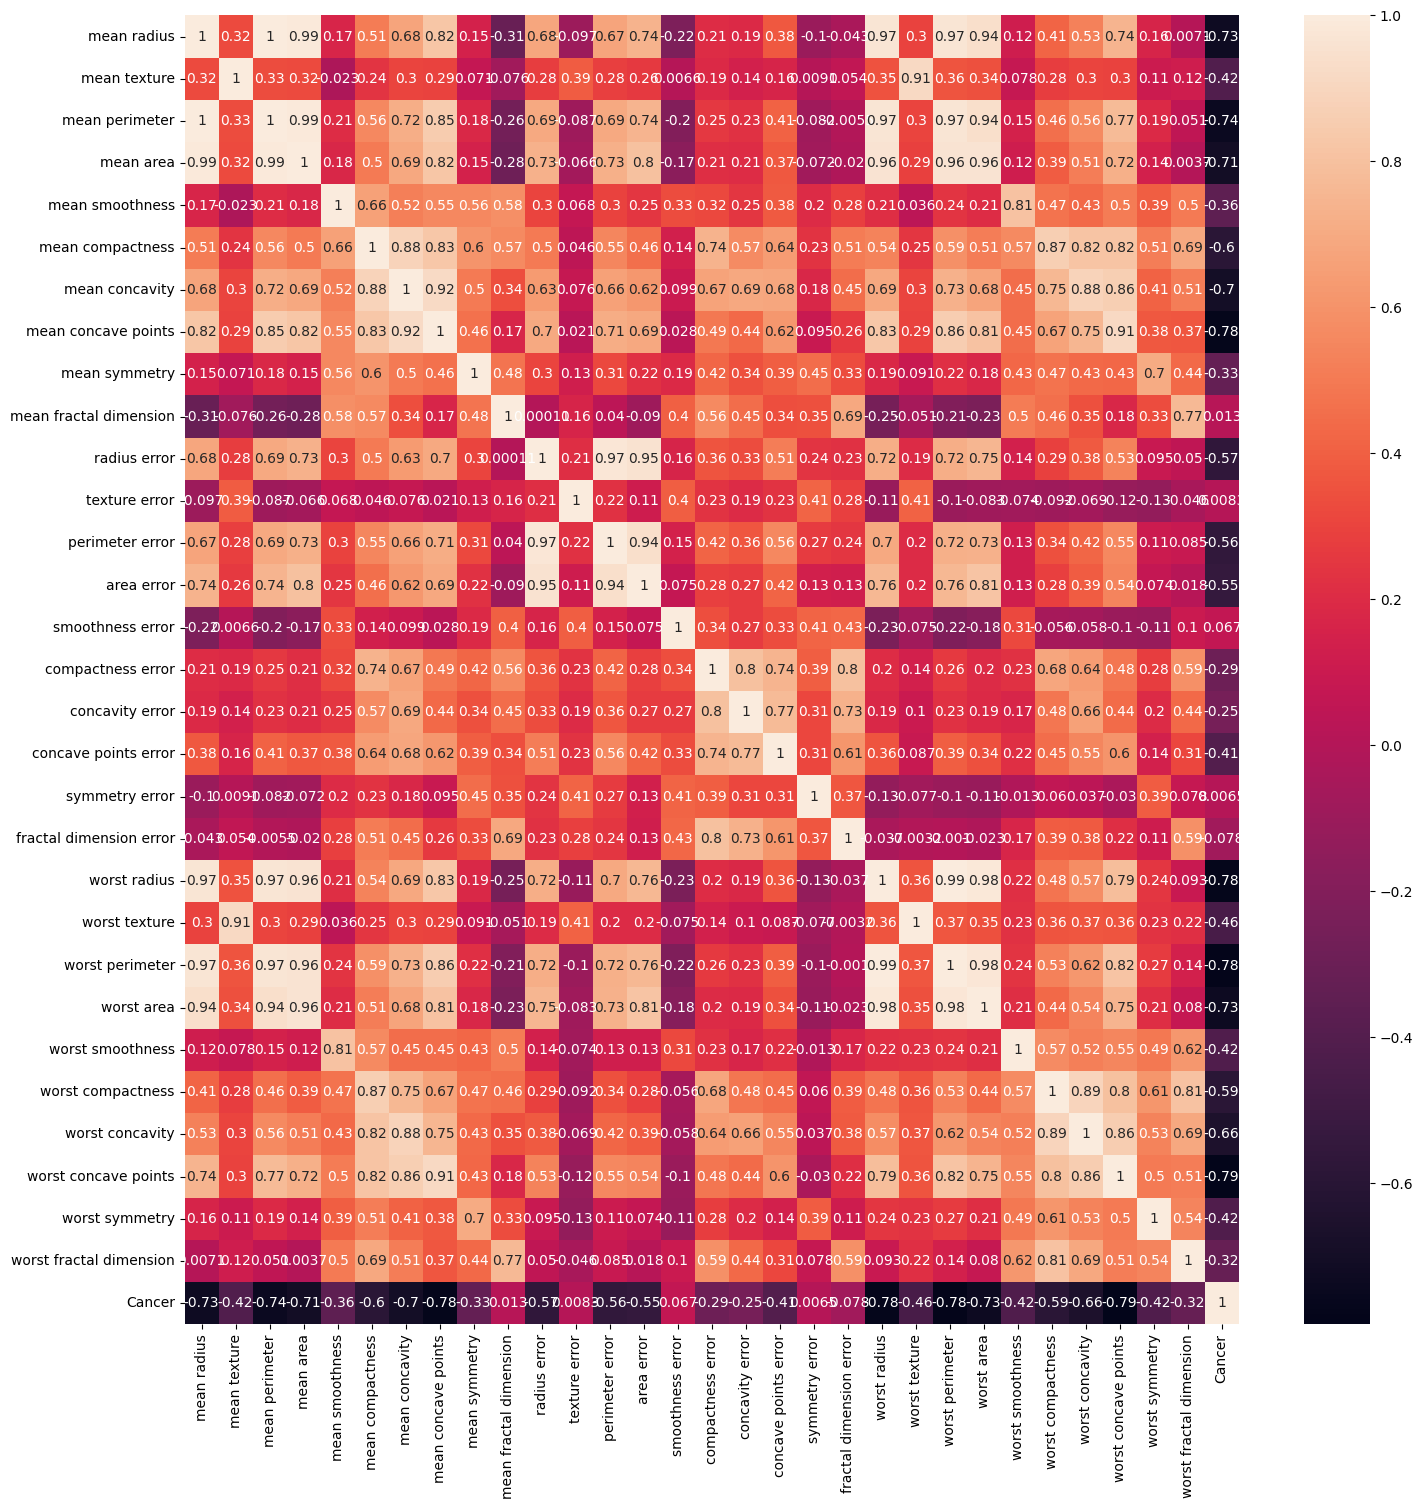

In [ ]:
data=df.corr()
plt.figure(figsize=(17,17))
sns.heatmap(data,annot=True)

## model training

In [ ]:
x=df.drop("Cancer",axis=1)
y=df["Cancer"]

In [ ]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=42)

In [ ]:
model=LogisticRegression()
model.fit(xtrain,ytrain)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
ypred=model.predict(xtest)

In [ ]:
confusion_matrix(ytest,ypred)

array([[ 59,   4],
       [  1, 107]])

In [ ]:
accuracy_score(ytest,ypred)

0.9707602339181286

In [ ]:
print("class_report:",classification_report(ytest,ypred))

class_report:               precision    recall  f1-score   support

           0       0.98      0.94      0.96        63
           1       0.96      0.99      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



In [ ]:
print("training eff: ",model.score(xtrain,ytrain))
print("testing eff: ",model.score(xtest,ytest))

training eff:  0.9346733668341709
testing eff:  0.9707602339181286


In [ ]:
new_data=df.iloc[48:49,:-1]
pred=model.predict(new_data)
prob=model.predict_proba(new_data)
if pred==0:
  print("no sign of cancer ")
else:
  print("sign of cancer")
print("probability :", prob)


sign of cancer
probability : [[0.02165734 0.97834266]]
